In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("bank.csv", sep=",")

In [9]:
df.head()

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
0,"59,admin.,married,secondary,no,2343,yes,no,unk..."
1,"56,admin.,married,secondary,no,45,no,no,unknow..."
2,"41,technician,married,secondary,no,1270,yes,no..."
3,"55,services,married,secondary,no,2476,yes,no,u..."
4,"54,admin.,married,tertiary,no,184,no,no,unknow..."


In [10]:
df.shape

(11162, 1)

In [11]:
df.columns

Index(['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit'], dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit  11162 non-null  object
dtypes: object(1)
memory usage: 87.3+ KB


In [13]:
df.isnull().sum()

,0
"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit",0


In [14]:
df.isnull().sum()

,0
"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit",0


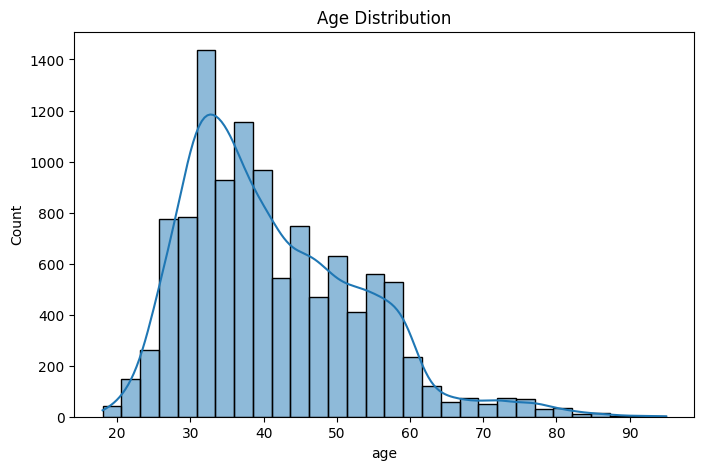

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

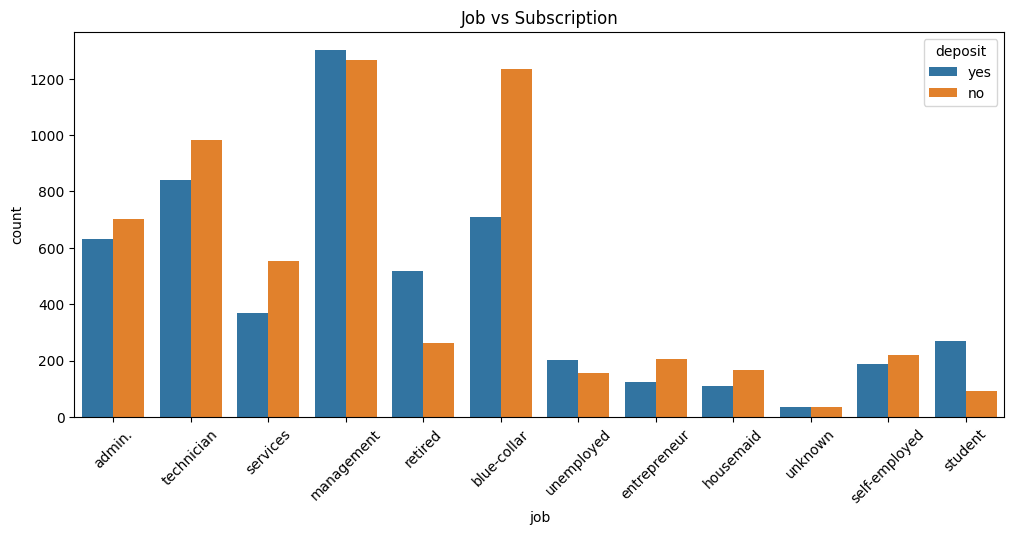

In [24]:
plt.figure(figsize=(12,5))
sns.countplot(x="job", hue="deposit", data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

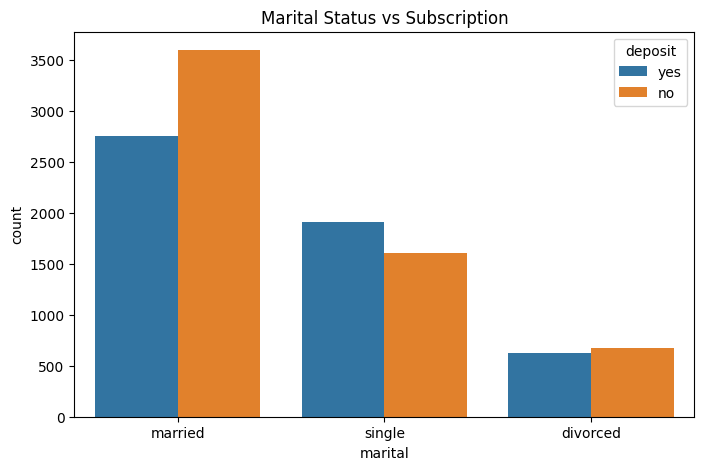

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x="marital", hue="deposit", data=df)
plt.title("Marital Status vs Subscription")
plt.show()

Confusion Matrix:
[[955 211]
 [258 809]]
F1 Score:
0.7752755150934355


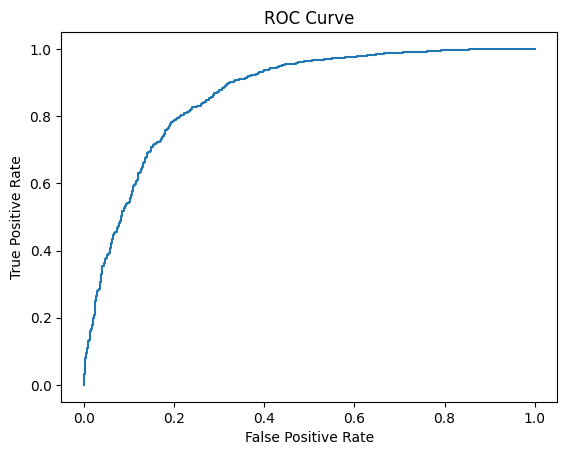

AUC Score: 0.8667429721522488


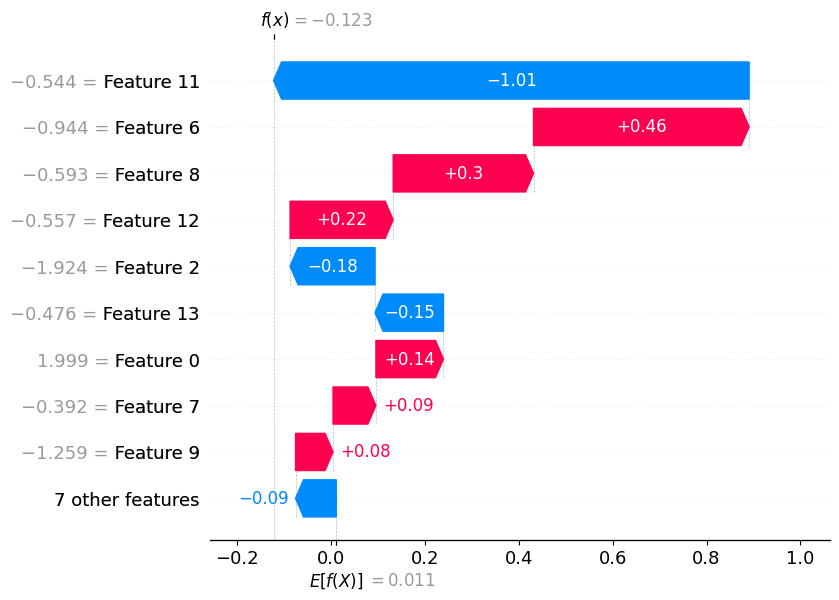

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, roc_auc_score
import shap

# Load dataset
df = pd.read_csv("bank.csv", sep=",")

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# Split data
X = df.drop("deposit", axis=1)
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("F1 Score:")
print(f1_score(y_test, y_pred))

# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

# SHAP Explainability
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])